In [1]:
import pandas as pd
df=pd.read_csv("/content/Food_Delivery_Times.csv")

In [2]:
df=df.drop(columns='Unnamed: 9')

In [3]:
df=df.drop(columns='Unnamed: 10')
df=df.drop(columns='Unnamed: 11')
df=df.drop(columns='Unnamed: 12')

In [ ]:
df.dropna(inplace=True)

In [ ]:
prep_time = df['Preparation_Time_min']
delivery_time = df['Delivery_Time_min']

In [ ]:
from scipy import stats
t_stat, p_value = stats.ttest_ind(prep_time, delivery_time)

In [ ]:
print(p_value)

0.0


In [ ]:
alpha = 0.05
if p_value < alpha:
    print("Reject H0: Evidence that mean weight differs from 60g")
else:
    print("Fail to reject H0: No evidence mean differs from 60g")

Reject H0: Evidence that mean weight differs from 60g


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [ ]:
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [ ]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='median')
df['Courier_Experience_yrs']=imputer.fit_transform(df[['Courier_Experience_yrs']])

In [ ]:
df=pd.get_dummies(df,columns=['Weather'],dtype=int)

In [ ]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [ ]:
df.drop(columns=['Order_ID'],inplace=True)

In [ ]:
df.columns

Index(['Distance_km', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type',
       'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min',
       'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12',
       'Weather_Clear', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy',
       'Weather_Windy'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df['Vehicle_Type']=oe.fit_transform(df[['Vehicle_Type']])
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,2.0,12,1.0,43
1,738,16.42,Clear,Medium,Evening,0.0,20,2.0,84
2,741,9.52,Foggy,Low,Night,2.0,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,2.0,5,1.0,37
4,412,19.03,Clear,Low,Morning,0.0,16,5.0,68


In [ ]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='most_frequent')
df['Time_of_Day']=imputer.fit_transform(df[['Time_of_Day']]).ravel()
df.isnull().sum()


,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [ ]:
df=df.rename(columns={'Weather_Rainy':'Weather_Rainyyyy'})

<Axes: ylabel='Delivery_Time_min'>

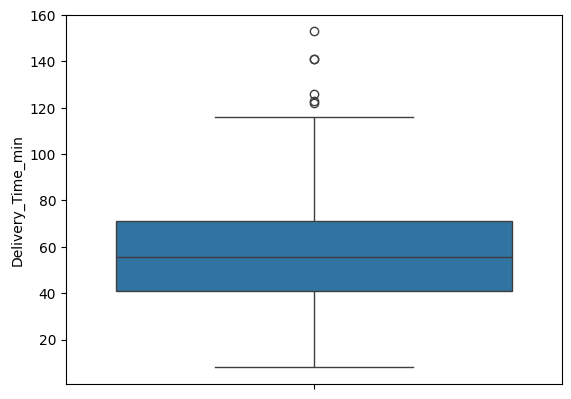

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(df['Delivery_Time_min'])

In [9]:
df['Delivery_Time_min'].describe()

,Delivery_Time_min
count,1000.000000
mean,56.732000
std,22.070915
min,8.000000
25%,41.000000
50%,55.500000
75%,71.000000
max,153.000000


In [8]:
Q1 = df['Delivery_Time_min'].quantile(0.25)
Q3 = df['Delivery_Time_min'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

30.0


In [7]:
# Remove points outside 1.5*IQR
upper_bound = Q3 + 1.5*IQR
lower_bound = Q1 - 1.5*IQR
df_clean = df[(df['Delivery_Time_min'] >= upper_bound) &
              (df['Delivery_Time_min'] <= lower_bound)]

In [10]:
import numpy as np

x=[1,2,3,4,5,6,7,90]
print(np.std(x))


28.50328928387038


In [ ]:
cleaned.describe()

,Distance_km,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Unnamed: 12,Weather_Clear,Weather_Foggy,Weather_Rainyyyy,Weather_Snowy,Weather_Windy
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.059970,0.799000,16.982000,4.592000,56.732000,0.0,0.470000,0.103000,0.204000,0.097000,0.096000
std,5.696656,0.874851,7.204553,2.871198,22.070915,NaN,0.499349,0.304111,0.403171,0.296106,0.294739
min,0.590000,0.000000,5.000000,0.000000,8.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.105000,0.000000,11.000000,2.000000,41.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10.190000,0.000000,17.000000,5.000000,55.500000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
75%,15.017500,2.000000,23.000000,7.000000,71.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000
max,19.990000,2.000000,29.000000,9.000000,153.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Try Z-score first (works well for right-skewed!)
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(df['Delivery_Time_min']))
df_clean = df[z_scores < 2]  # Change threshold as needed

# Check result
print(df_clean.describe())  # Should show improvement!

       Distance_km  Vehicle_Type  Preparation_Time_min  \
count   965.000000    965.000000            965.000000   
mean      9.859523      0.806218             16.890155   
std       5.617962      0.876599              7.214724   
min       0.590000      0.000000              5.000000   
25%       4.880000      0.000000             11.000000   
50%      10.040000      1.000000             17.000000   
75%      14.660000      2.000000             23.000000   
max      19.940000      2.000000             29.000000   

       Courier_Experience_yrs  Delivery_Time_min  
count              965.000000         965.000000  
mean                 4.635233          54.822798  
std                  2.873834          19.608267  
min                  0.000000          13.000000  
25%                  2.000000          40.000000  
50%                  5.000000          54.000000  
75%                  7.000000          70.000000  
max                  9.000000         100.000000  


In [11]:
Q1 = df_clean['Delivery_Time_min'].quantile(0.25)
Q3 = df_clean['Delivery_Time_min'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

nan


stats.zscore(df['Delivery_Time_min'])
    ↓
Formula: z = (x - mean) / std

Example:
Delivery times: [30, 45, 50, 55, 60, 65, 200]
Mean = 72, Std = 55

Z-scores:
30 → (30-72)/55 = -0.76
45 → (45-72)/55 = -0.49
50 → (50-72)/55 = -0.40
55 → (55-72)/55 = -0.31
60 → (60-72)/55 = -0.22
65 → (65-72)/55 = -0.13
200 → (200-72)/55 = 2.33  ← High z-score!

np.abs() → Absolute value (negative ah positive)
So -0.76 becomes 0.76, -0.49 becomes 0.49


Threshold	Meaning	When to Use
2	Strict	Remove more outliers
2.5	Medium	Good for right-skewed
3	Lenient	Remove only extreme outliers

In [ ]:
df['Delivery_Time_min'].skew()

np.float64(0.5072511816152696)

In [ ]:
from scipy import stats
import numpy as np
z_score=np.abs(stats.zscore(df['Delivery_Time_min']))
df_clean=df[z_score <2]

In [ ]:
df_clean['Delivery_Time_min'].skew()

np.float64(0.1245920815436434)

<Axes: xlabel='Delivery_Time_min', ylabel='Density'>

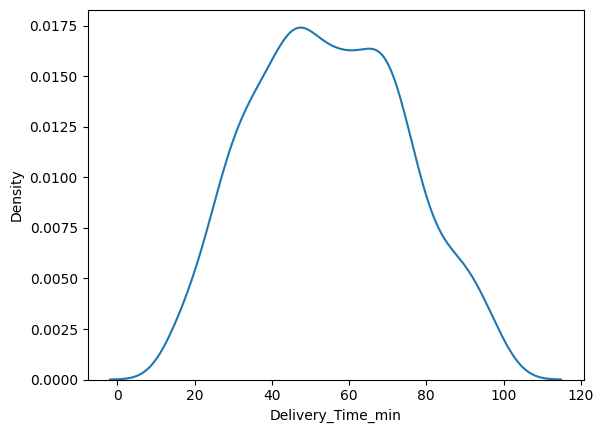

In [ ]:
sns.kdeplot(df_clean['Delivery_Time_min'])

<Axes: ylabel='Delivery_Time_min'>

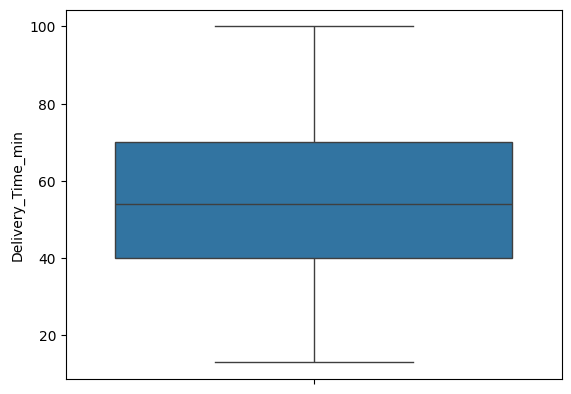

In [ ]:
sns.boxplot(df_clean['Delivery_Time_min'])

Original Data → Scaled Data
[10, 20, 30, 40, 50] → [0, 0.25, 0.5, 0.75, 1]

Scaled_Value = (Original_Value - Min) / (Max - Min)

Result always between 0 and 1!

In [ ]:
import pandas as pd
df=pd.read_csv("/content/Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,NaN,NaN,NaN,NaN
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,NaN,NaN,NaN,NaN
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,NaN,NaN,NaN,NaN
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,56732,NaN,NaN,NaN
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,78156,NaN,NaN,NaN


In [ ]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Unnamed: 12
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000,1.0
mean,500.500000,10.059970,16.982000,4.579381,56.732000,0.0
std,288.819436,5.696656,7.204553,2.914394,22.070915,NaN
min,1.000000,0.590000,5.000000,0.000000,8.000000,0.0
25%,250.750000,5.105000,11.000000,2.000000,41.000000,0.0
50%,500.500000,10.190000,17.000000,5.000000,55.500000,0.0
75%,750.250000,15.017500,23.000000,7.000000,71.000000,0.0
max,1000.000000,19.990000,29.000000,9.000000,153.000000,0.0


<Axes: xlabel='Delivery_Time_min', ylabel='Density'>

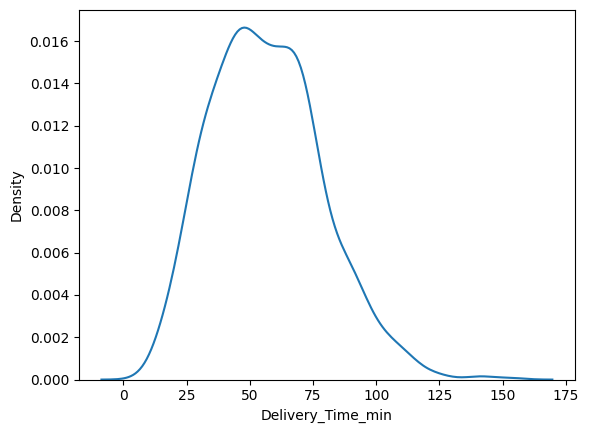

In [ ]:
import seaborn as sns
sns.kdeplot(df['Delivery_Time_min'])

In [ ]:
import numpy as np
from scipy import stats

In [ ]:
z_score=np.abs(stats.zscore(df['Delivery_Time_min']))
df_clean=df[z_score <2]

In [ ]:
df_clean.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Unnamed: 12
count,965.000000,965.000000,965.000000,935.000000,965.000000,1.0
mean,502.237306,9.859523,16.890155,4.623529,54.822798,0.0
std,289.038886,5.617962,7.214724,2.918868,19.608267,NaN
min,1.000000,0.590000,5.000000,0.000000,13.000000,0.0
25%,253.000000,4.880000,11.000000,2.000000,40.000000,0.0
50%,504.000000,10.040000,17.000000,5.000000,54.000000,0.0
75%,752.000000,14.660000,23.000000,7.000000,70.000000,0.0
max,1000.000000,19.940000,29.000000,9.000000,100.000000,0.0


In [ ]:
import numpy as np
from scipy import stats
z_score=np.abs(stats.zscore(df['Delivery_Time_min']))
df_clean=df[z_score <2]

In [ ]:
df_clean.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Unnamed: 12
count,965.000000,965.000000,965.000000,935.000000,965.000000,1.0
mean,502.237306,9.859523,16.890155,4.623529,54.822798,0.0
std,289.038886,5.617962,7.214724,2.918868,19.608267,NaN
min,1.000000,0.590000,5.000000,0.000000,13.000000,0.0
25%,253.000000,4.880000,11.000000,2.000000,40.000000,0.0
50%,504.000000,10.040000,17.000000,5.000000,54.000000,0.0
75%,752.000000,14.660000,23.000000,7.000000,70.000000,0.0
max,1000.000000,19.940000,29.000000,9.000000,100.000000,0.0


<Axes: ylabel='Delivery_Time_min'>

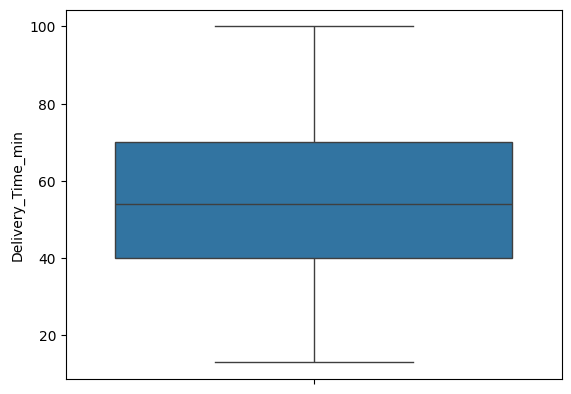

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(df_clean['Delivery_Time_min'])

In [ ]:
df_clean.drop(columns='Unnamed: 12',axis=1)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,NaN,NaN,NaN
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,NaN,NaN,NaN
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,NaN,NaN,NaN
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,56732,NaN,NaN
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,78156,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54,NaN,NaN,NaN
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71,NaN,NaN,NaN
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81,NaN,NaN,NaN
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55,NaN,NaN,NaN


In [ ]:
df_clean.drop(columns='Unnamed: 11',axis=1,inplace=True)
df_clean.drop(columns='Unnamed: 10',axis=1,inplace=True)
df_clean.drop(columns='Unnamed: 9',axis=1,inplace=True)

/tmp/ipykernel_11028/1440801620.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(columns='Unnamed: 11',axis=1,inplace=True)
/tmp/ipykernel_11028/1440801620.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(columns='Unnamed: 10',axis=1,inplace=True)
/tmp/ipykernel_11028/1440801620.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(columns='Unnamed: 9',axis=1,inplace=True)


In [ ]:
df_clean.drop(columns='Unnamed: 12',axis=1,inplace=True)

/tmp/ipykernel_11028/1490843007.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(columns='Unnamed: 12',axis=1,inplace=True)


In [ ]:
df_clean.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,965.000000,965.000000,965.000000,935.000000,965.000000
mean,502.237306,9.859523,16.890155,4.623529,54.822798
std,289.038886,5.617962,7.214724,2.918868,19.608267
min,1.000000,0.590000,5.000000,0.000000,13.000000
25%,253.000000,4.880000,11.000000,2.000000,40.000000
50%,504.000000,10.040000,17.000000,5.000000,54.000000
75%,752.000000,14.660000,23.000000,7.000000,70.000000
max,1000.000000,19.940000,29.000000,9.000000,100.000000


In [ ]:
df_clean

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_clean['Weather']=le.fit_transform(df_clean['Weather'])
df_clean['Time_of_Day']=le.fit_transform(df_clean['Time_of_Day'])
df_clean['Vehicle_Type']=le.fit_transform(df_clean['Vehicle_Type'])
df_clean['Traffic_Level']=le.fit_transform(df_clean['Traffic_Level'])
df_clean

/tmp/ipykernel_11028/158042596.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Weather']=le.fit_transform(df_clean['Weather'])
/tmp/ipykernel_11028/158042596.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Time_of_Day']=le.fit_transform(df_clean['Time_of_Day'])
/tmp/ipykernel_11028/158042596.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,4,1,0,2,12,1.0,43
1,738,16.42,0,2,1,0,20,2.0,84
2,741,9.52,1,1,3,2,28,1.0,59
3,661,7.44,2,2,0,2,5,1.0,37
4,412,19.03,0,1,2,0,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,0,0,1,1,13,3.0,54
996,271,16.28,2,1,2,2,8,9.0,71
997,861,15.62,3,0,1,2,26,2.0,81
998,436,14.17,0,1,0,0,8,0.0,55


In [ ]:
df_clean.isnull().sum()
df_clean['Courier_Experience_yrs']=df_clean['Courier_Experience_yrs'].fillna(df_clean['Courier_Experience_yrs'].mean())

/tmp/ipykernel_11028/3102922263.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Courier_Experience_yrs']=df_clean['Courier_Experience_yrs'].fillna(df_clean['Courier_Experience_yrs'].mean())


In [ ]:
df_clean.dropna(inplace=True)

/tmp/ipykernel_3694/1832953665.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.dropna(inplace=True)


In [ ]:
df_clean.isnull().sum().sum()

np.int64(0)

In [ ]:
df_clean.drop(columns='Order_ID',inplace=True,axis=1)

/tmp/ipykernel_11028/3193635898.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(columns='Order_ID',inplace=True,axis=1)


In [ ]:
x=df_clean.drop(columns='Delivery_Time_min',axis=1)
x

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,7.93,4,1,0,2,12,1.0
1,16.42,0,2,1,0,20,2.0
2,9.52,1,1,3,2,28,1.0
3,7.44,2,2,0,2,5,1.0
4,19.03,0,1,2,0,16,5.0
...,...,...,...,...,...,...,...
995,8.50,0,0,1,1,13,3.0
996,16.28,2,1,2,2,8,9.0
997,15.62,3,0,1,2,26,2.0
998,14.17,0,1,0,0,8,0.0


In [ ]:
y=df_clean['Delivery_Time_min']
y

,Delivery_Time_min
0,43
1,84
2,59
3,37
4,68
...,...
995,54
996,71
997,81
998,55


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=sc.fit_transform(x)
x

array([[-0.34363417,  1.76843628, -0.32786329, ...,  1.36254003,
        -0.67815365, -1.26184963],
       [ 1.16837353, -0.86918506,  0.92764495, ..., -0.92018763,
         0.43126491, -0.91361191],
       [-0.06046665, -0.20977973, -0.32786329, ...,  1.36254003,
         1.54068347, -1.26184963],
       ...,
       [ 1.02589931,  1.10903094, -1.58337153, ...,  1.36254003,
         1.26332883, -0.91361191],
       [ 0.76766478, -0.86918506, -0.32786329, ..., -0.92018763,
        -1.23286293, -1.61008736],
       [-0.57515479, -0.20977973, -0.32786329, ...,  1.36254003,
         0.98597419, -0.56537419]])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.30, random_state=42)

In [ ]:
x_train.shape

(654, 7)

In [ ]:
x_test.shape

(281, 7)

In [ ]:
y_test.shape

(281,)

In [ ]:
y_train.shape

(654,)

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_train)

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_train,y_pred))
print(mean_absolute_error(y_train,y_pred))

0.769307106595333
6.802391017074884


In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.8226598335791586
6.228238958238669


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)
y_pred=dt.predict(x_train)
#y_pred

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_train,y_pred))
print(mean_absolute_error(y_train,y_pred))


1.0
0.0


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.6520841534968693
8.46896551724138


In [ ]:
# Gini
dt_gini = DecisionTreeRegressor(criterion='squared_error')  # default
dt_gini.fit(x_train, y_train)
y_pred_gini = dt_gini.predict(x_train)
print("Gini R2:", r2_score(y_train, y_pred_gini))

# Entropy (friedman_mse for regressor)
dt_entropy = DecisionTreeRegressor(criterion='friedman_mse')
dt_entropy.fit(x_train, y_train)
y_pred_entropy = dt_entropy.predict(x_train)
print("Entropy R2:", r2_score(y_train, y_pred_entropy))

Gini R2: 1.0
Entropy R2: 1.0


In [ ]:
dt_gini = DecisionTreeRegressor(criterion='squared_error')  # default
dt_gini.fit(x_train, y_train)
y_pred_gini = dt_gini.predict(x_test)
print("Gini R2:", r2_score(y_test, y_pred_gini))

# Entropy (friedman_mse for regressor)
dt_entropy = DecisionTreeRegressor(criterion='friedman_mse')
dt_entropy.fit(x_train, y_train)
y_pred_entropy = dt_entropy.predict(x_test)
print("Entropy R2:", r2_score(y_test, y_pred_entropy))

Gini R2: 0.6234754856280953
Entropy R2: 0.6450515879839768


In [ ]:
# Pruning = max_depth limit
dt_pruned = DecisionTreeRegressor(criterion='friedman_mse', max_depth=4)
dt_pruned.fit(x_train, y_train)
y_pred_pruned = dt_pruned.predict(x_train)

print("Pruned R2:", r2_score(y_train, y_pred_pruned))
print("Pruned MAE:", mean_absolute_error(y_train, y_pred_pruned))

Pruned R2: 0.7695237844202445
Pruned MAE: 7.214279556707881


In [ ]:
dt_pruned = DecisionTreeRegressor(criterion='friedman_mse', max_depth=4)
dt_pruned.fit(x_train, y_train)
y_pred_pruned = dt_pruned.predict(x_test)

print("Pruned R2:", r2_score(y_test, y_pred_pruned))
print("Pruned MAE:", mean_absolute_error(y_test, y_pred_pruned))

Pruned R2: 0.7400061040239255
Pruned MAE: 7.866889556203303


In [ ]:
for depth in range(2, 10):
    dt = DecisionTreeRegressor(max_depth=depth)
    dt.fit(x_train, y_train)
    pred = dt.predict(x_train)
    print(f"Depth {depth} → R2: {r2_score(y_train, pred):.4f}")

Depth 2 → R2: 0.6394
Depth 3 → R2: 0.7186
Depth 4 → R2: 0.7695
Depth 5 → R2: 0.8166
Depth 6 → R2: 0.8556
Depth 7 → R2: 0.8943
Depth 8 → R2: 0.9259
Depth 9 → R2: 0.9576


In [ ]:
for depth in range(2, 10):
    dt = DecisionTreeRegressor(max_depth=depth)
    dt.fit(x_train, y_train)
    pred = dt.predict(x_test)
    print(f"Depth {depth} → R2: {r2_score(y_test, pred):.4f}")

Depth 2 → R2: 0.5962
Depth 3 → R2: 0.6946
Depth 4 → R2: 0.7400
Depth 5 → R2: 0.7361
Depth 6 → R2: 0.7243
Depth 7 → R2: 0.6875
Depth 8 → R2: 0.6622
Depth 9 → R2: 0.6544


In [ ]:
dt_pruned = DecisionTreeRegressor(
    criterion='friedman_mse',
    max_depth=4,              # tree depth limit
    min_samples_split=10,     # node split aaga minimum samples
    min_samples_leaf=5,       # leaf node la minimum samples
    ccp_alpha=0.01            # cost complexity pruning---Higher value = more pruning
)
dt_pruned.fit(x_train, y_train)
y_pred_pruned = dt_pruned.predict(x_train)

print("R2:", r2_score(y_train, y_pred_pruned))
print("MAE:", mean_absolute_error(y_train, y_pred_pruned))

R2: 0.7695237844202445
MAE: 7.214279556707881


In [ ]:
# max_depth
for val in range(2, 10):
    dt = DecisionTreeRegressor(max_depth=val)
    dt.fit(x_train, y_train)
    y_pred = dt.predict(x_train)
    print(f"max_depth={val} → R2: {r2_score(y_train, y_pred):.4f} MAE: {mean_absolute_error(y_train, y_pred):.4f}")

# min_samples_split
for val in range(2, 20, 2):
    dt = DecisionTreeRegressor(min_samples_split=val)
    dt.fit(x_train, y_train)
    y_pred = dt.predict(x_train)
    print(f"min_samples_split={val} → R2: {r2_score(y_train, y_pred):.4f} MAE: {mean_absolute_error(y_train, y_pred):.4f}")

# min_samples_leaf
for val in range(1, 20, 2):
    dt = DecisionTreeRegressor(min_samples_leaf=val)
    dt.fit(x_train, y_train)
    y_pred = dt.predict(x_train)
    print(f"min_samples_leaf={val} → R2: {r2_score(y_train, y_pred):.4f} MAE: {mean_absolute_error(y_train, y_pred):.4f}")

# ccp_alpha
for val in [0.0, 0.001, 0.01, 0.05, 0.1, 0.2]:
    dt = DecisionTreeRegressor(ccp_alpha=val)
    dt.fit(x_train, y_train)
    y_pred = dt.predict(x_train)
    print(f"ccp_alpha={val} → R2: {r2_score(y_train, y_pred):.4f} MAE: {mean_absolute_error(y_train, y_pred):.4f}")

max_depth=2 → R2: 0.6394 MAE: 9.3966
max_depth=3 → R2: 0.7186 MAE: 8.0266
max_depth=4 → R2: 0.7695 MAE: 7.2143
max_depth=5 → R2: 0.8166 MAE: 6.5032
max_depth=6 → R2: 0.8556 MAE: 5.4477
max_depth=7 → R2: 0.8943 MAE: 4.5147
max_depth=8 → R2: 0.9259 MAE: 3.4498
max_depth=9 → R2: 0.9576 MAE: 2.3121
min_samples_split=2 → R2: 1.0000 MAE: 0.0000
min_samples_split=4 → R2: 0.9773 MAE: 1.5773
min_samples_split=6 → R2: 0.9575 MAE: 2.7176
min_samples_split=8 → R2: 0.9223 MAE: 3.7077
min_samples_split=10 → R2: 0.9034 MAE: 4.2259
min_samples_split=12 → R2: 0.8928 MAE: 4.5629
min_samples_split=14 → R2: 0.8832 MAE: 4.8176
min_samples_split=16 → R2: 0.8764 MAE: 5.0091
min_samples_split=18 → R2: 0.8670 MAE: 5.2660
min_samples_leaf=1 → R2: 1.0000 MAE: 0.0000
min_samples_leaf=3 → R2: 0.9229 MAE: 3.7795
min_samples_leaf=5 → R2: 0.8794 MAE: 4.9459
min_samples_leaf=7 → R2: 0.8524 MAE: 5.5665
min_samples_leaf=9 → R2: 0.8377 MAE: 5.9733
min_samples_leaf=11 → R2: 0.8186 MAE: 6.3462
min_samples_leaf=13 → R2: 0.8

In [ ]:
# min_samples_split
for val in range(2, 20, 2):
    dt = DecisionTreeRegressor(min_samples_split=val)
    dt.fit(x_train, y_train)
    y_pred = dt.predict(x_train)
    print(f"min_samples_split={val} → R2: {r2_score(y_train, y_pred):.4f} MAE: {mean_absolute_error(y_train, y_pred):.4f}")

min_samples_split=2 → R2: 1.0000 MAE: 0.0000
min_samples_split=4 → R2: 0.9774 MAE: 1.5827
min_samples_split=6 → R2: 0.9575 MAE: 2.7099
min_samples_split=8 → R2: 0.9223 MAE: 3.7077
min_samples_split=10 → R2: 0.9035 MAE: 4.2211
min_samples_split=12 → R2: 0.8928 MAE: 4.5629
min_samples_split=14 → R2: 0.8832 MAE: 4.8176
min_samples_split=16 → R2: 0.8764 MAE: 5.0120
min_samples_split=18 → R2: 0.8670 MAE: 5.2630


In [ ]:
dt_pruned = DecisionTreeRegressor(criterion='friedman_mse', max_depth=9,min_samples_split=4)
dt_pruned.fit(x_train, y_train)
y_pred_pruned = dt_pruned.predict(x_train)

print("Pruned R2:", r2_score(y_train, y_pred_pruned))
print("Pruned MAE:", mean_absolute_error(y_train, y_pred_pruned))

Pruned R2: 0.9431567563042788
Pruned MAE: 2.9545365024077666


In [ ]:
# min_samples_split
for val in range(2, 20, 2):
    dt = DecisionTreeRegressor(min_samples_split=val)
    dt.fit(x_train, y_train)
    y_pred = dt.predict(x_test)
    print(f"min_samples_split={val} → R2: {r2_score(y_test, y_pred):.4f} MAE: {mean_absolute_error(y_test, y_pred):.4f}")

min_samples_split=2 → R2: 0.6528 MAE: 8.3621
min_samples_split=4 → R2: 0.6697 MAE: 8.3557
min_samples_split=6 → R2: 0.6801 MAE: 8.1521
min_samples_split=8 → R2: 0.7126 MAE: 7.8056
min_samples_split=10 → R2: 0.7105 MAE: 7.8254
min_samples_split=12 → R2: 0.7249 MAE: 7.6324
min_samples_split=14 → R2: 0.7380 MAE: 7.5187
min_samples_split=16 → R2: 0.7441 MAE: 7.4346
min_samples_split=18 → R2: 0.7481 MAE: 7.3905


In [ ]:
dt_pruned = DecisionTreeRegressor(criterion='friedman_mse', max_depth=4,min_samples_split=18)
dt_pruned.fit(x_train, y_train)
y_pred_pruned = dt_pruned.predict(x_test)

print("Pruned R2:", r2_score(y_test, y_pred_pruned))
print("Pruned MAE:", mean_absolute_error(y_test, y_pred_pruned))

Pruned R2: 0.7379016061363823
Pruned MAE: 7.923929786088362


In [ ]:
# min_samples_leaf
for val in range(1, 20, 2):
    dt = DecisionTreeRegressor(min_samples_leaf=val)
    dt.fit(x_train, y_train)
    y_pred = dt.predict(x_train)
    print(f"min_samples_leaf={val} → R2: {r2_score(y_train, y_pred):.4f} MAE: {mean_absolute_error(y_train, y_pred):.4f}")

min_samples_leaf=1 → R2: 1.0000 MAE: 0.0000
min_samples_leaf=3 → R2: 0.9229 MAE: 3.7760
min_samples_leaf=5 → R2: 0.8794 MAE: 4.9459
min_samples_leaf=7 → R2: 0.8524 MAE: 5.5665
min_samples_leaf=9 → R2: 0.8377 MAE: 5.9733
min_samples_leaf=11 → R2: 0.8186 MAE: 6.3462
min_samples_leaf=13 → R2: 0.8090 MAE: 6.4136
min_samples_leaf=15 → R2: 0.7986 MAE: 6.5579
min_samples_leaf=17 → R2: 0.7868 MAE: 6.7683
min_samples_leaf=19 → R2: 0.7865 MAE: 6.7681


In [ ]:
dt_pruned = DecisionTreeRegressor(criterion='friedman_mse', max_depth=9,min_samples_split=4,min_samples_leaf=3)
dt_pruned.fit(x_train, y_train)
y_pred_pruned = dt_pruned.predict(x_train)

print("Pruned R2:", r2_score(y_train, y_pred_pruned))
print("Pruned MAE:", mean_absolute_error(y_train, y_pred_pruned))

Pruned R2: 0.9108569525244299
Pruned MAE: 4.075409972743306


In [ ]:
dt_pruned = DecisionTreeRegressor(criterion='friedman_mse', max_depth=9,min_samples_split=4,min_samples_leaf=11)
dt_pruned.fit(x_train, y_train)
y_pred_pruned = dt_pruned.predict(x_test)

print("Pruned R2:", r2_score(y_test, y_pred_pruned))
print("Pruned MAE:", mean_absolute_error(y_test, y_pred_pruned))

Pruned R2: 0.7627009457292507
Pruned MAE: 7.47686395782491


In [ ]:
# min_samples_leaf
for val in range(1, 20, 2):
    dt = DecisionTreeRegressor(min_samples_leaf=val)
    dt.fit(x_train, y_train)
    y_pred = dt.predict(x_test)
    print(f"min_samples_leaf={val} → R2: {r2_score(y_test, y_pred):.4f} MAE: {mean_absolute_error(y_test, y_pred):.4f}")

min_samples_leaf=1 → R2: 0.6419 MAE: 8.5138
min_samples_leaf=3 → R2: 0.7283 MAE: 7.7762
min_samples_leaf=5 → R2: 0.7601 MAE: 7.2629
min_samples_leaf=7 → R2: 0.7551 MAE: 7.4608
min_samples_leaf=9 → R2: 0.7431 MAE: 7.6224
min_samples_leaf=11 → R2: 0.7627 MAE: 7.4769
min_samples_leaf=13 → R2: 0.7646 MAE: 7.4540
min_samples_leaf=15 → R2: 0.7564 MAE: 7.5778
min_samples_leaf=17 → R2: 0.7584 MAE: 7.6328
min_samples_leaf=19 → R2: 0.7584 MAE: 7.6157


In [ ]:
# ccp_alpha
for val in [0.0, 0.001, 0.01, 0.05, 0.1, 0.2]:
    dt = DecisionTreeRegressor(ccp_alpha=val)
    dt.fit(x_train, y_train)
    y_pred = dt.predict(x_train)
    print(f"ccp_alpha={val} → R2: {r2_score(y_train, y_pred):.4f} MAE: {mean_absolute_error(y_train, y_pred):.4f}")

ccp_alpha=0.0 → R2: 1.0000 MAE: 0.0000
ccp_alpha=0.001 → R2: 0.9998 MAE: 0.1279
ccp_alpha=0.01 → R2: 0.9984 MAE: 0.5384
ccp_alpha=0.05 → R2: 0.9895 MAE: 1.5290
ccp_alpha=0.1 → R2: 0.9764 MAE: 2.3994
ccp_alpha=0.2 → R2: 0.9515 MAE: 3.4502


In [ ]:
# ccp_alpha
for val in [0.0, 0.001, 0.01, 0.05, 0.1, 0.2]:
    dt = DecisionTreeRegressor(ccp_alpha=val)
    dt.fit(x_train, y_train)
    y_pred = dt.predict(x_test)
    print(f"ccp_alpha={val} → R2: {r2_score(y_test, y_pred):.4f} MAE: {mean_absolute_error(y_test, y_pred):.4f}")

ccp_alpha=0.0 → R2: 0.6514 MAE: 8.4862
ccp_alpha=0.001 → R2: 0.6519 MAE: 8.5293
ccp_alpha=0.01 → R2: 0.6511 MAE: 8.3670
ccp_alpha=0.05 → R2: 0.6571 MAE: 8.4346
ccp_alpha=0.1 → R2: 0.6583 MAE: 8.2906
ccp_alpha=0.2 → R2: 0.6720 MAE: 8.1179


In [ ]:
dt_pruned = DecisionTreeRegressor(criterion='friedman_mse', max_depth=9,min_samples_split=4,min_samples_leaf=3,ccp_alpha=0.001)
dt_pruned.fit(x_train, y_train)
y_pred_pruned = dt_pruned.predict(x_train)

print("Pruned R2:", r2_score(y_train, y_pred_pruned))
print("Pruned MAE:", mean_absolute_error(y_train, y_pred_pruned))

Pruned R2: 0.910854439236453
Pruned MAE: 4.074422318422319


In [ ]:
dt_pruned = DecisionTreeRegressor(criterion='friedman_mse', max_depth=9,min_samples_split=4,min_samples_leaf=3,ccp_alpha=0.001)
dt_pruned.fit(x_train, y_train)
y_pred_pruned = dt_pruned.predict(x_test)

print("Pruned R2:", r2_score(y_test, y_pred_pruned))
print("Pruned MAE:", mean_absolute_error(y_test, y_pred_pruned))

Pruned R2: 0.7387673752118011
Pruned MAE: 7.670020152261531


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(x_train,y_train)
y_pred=rf.predict(x_train)

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_train,y_pred))
print(mean_absolute_error(y_train,y_pred))

0.967231863323669
2.547125925925926


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.8218247782935468
6.330413793103449


In [ ]:
print("\n1. TUNING n_estimators:")
print("-"*40)
for val in [10, 50, 100, 200, 300, 500]:
    rf = RandomForestRegressor(n_estimators=val, random_state=42)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_train)
    print(f"n_estimators={val:3} → R²: {r2_score(y_train, y_pred):.4f} | MAE: {mean_absolute_error(y_train, y_pred):.4f}")


1. TUNING n_estimators:
----------------------------------------
n_estimators= 10 → R²: 0.9504 | MAE: 2.9241
n_estimators= 50 → R²: 0.9676 | MAE: 2.6146
n_estimators=100 → R²: 0.9679 | MAE: 2.5509
n_estimators=200 → R²: 0.9685 | MAE: 2.5145
n_estimators=300 → R²: 0.9685 | MAE: 2.5083
n_estimators=500 → R²: 0.9686 | MAE: 2.5033


In [ ]:
print("\n2. TUNING max_depth:")
print("-"*40)
for val in [3, 5, 7, 10, 15, 20, None]:
    rf = RandomForestRegressor(max_depth=val, random_state=42)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_train)
    print(f"max_depth={val if val is not None else 'None':>4} → R²: {r2_score(y_train, y_pred):.4f} | MAE: {mean_absolute_error(y_train, y_pred):.4f}")


2. TUNING max_depth:
----------------------------------------
max_depth=   3 → R²: 0.7617 | MAE: 7.2874
max_depth=   5 → R²: 0.8479 | MAE: 5.7350
max_depth=   7 → R²: 0.9192 | MAE: 4.2534
max_depth=  10 → R²: 0.9609 | MAE: 2.8940
max_depth=  15 → R²: 0.9679 | MAE: 2.5523
max_depth=  20 → R²: 0.9679 | MAE: 2.5509
max_depth=None → R²: 0.9679 | MAE: 2.5509


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=500,max_depth=20)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_train)

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_train,y_pred))
print(mean_absolute_error(y_train,y_pred))

0.9686659107802428
2.496369777777778


In [ ]:
print("\n1. TUNING n_estimators:")
print("-"*40)
for val in [10, 50, 100, 200, 300, 500]:
    rf = RandomForestRegressor(n_estimators=val, random_state=42)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_test)
    print(f"n_estimators={val:3} → R²: {r2_score(y_test, y_pred):.4f} | MAE: {mean_absolute_error(y_test, y_pred):.4f}")


1. TUNING n_estimators:
----------------------------------------
n_estimators= 10 → R²: 0.7872 | MAE: 6.8617
n_estimators= 50 → R²: 0.8076 | MAE: 6.5026
n_estimators=100 → R²: 0.8154 | MAE: 6.4241
n_estimators=200 → R²: 0.8158 | MAE: 6.4365
n_estimators=300 → R²: 0.8169 | MAE: 6.4097
n_estimators=500 → R²: 0.8179 | MAE: 6.3955


In [ ]:
print("\n2. TUNING max_depth:")
print("-"*40)
for val in [3, 5, 7, 10, 15, 20, None]:
    rf = RandomForestRegressor(max_depth=val, random_state=42)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_test)
    print(f"max_depth={val if val is not None else 'None':>4} → R²: {r2_score(y_test, y_pred):.4f} | MAE: {mean_absolute_error(y_test, y_pred):.4f}")


2. TUNING max_depth:
----------------------------------------
max_depth=   3 → R²: 0.7560 | MAE: 7.6013
max_depth=   5 → R²: 0.8003 | MAE: 6.8423
max_depth=   7 → R²: 0.8134 | MAE: 6.5380
max_depth=  10 → R²: 0.8137 | MAE: 6.4580
max_depth=  15 → R²: 0.8159 | MAE: 6.4220
max_depth=  20 → R²: 0.8154 | MAE: 6.4241
max_depth=None → R²: 0.8154 | MAE: 6.4241


In [ ]:
print("\n3. TUNING min_samples_split:")
print("-"*40)
for val in [2, 5, 10, 20, 50]:
    rf = RandomForestRegressor(min_samples_split=val, random_state=42)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_test)
    print(f"min_samples_split={val:2} → R²: {r2_score(y_test, y_pred):.4f} | MAE: {mean_absolute_error(y_test, y_pred):.4f}")


3. TUNING min_samples_split:
----------------------------------------
min_samples_split= 2 → R²: 0.8154 | MAE: 6.4241
min_samples_split= 5 → R²: 0.8190 | MAE: 6.3657
min_samples_split=10 → R²: 0.8186 | MAE: 6.4170
min_samples_split=20 → R²: 0.8109 | MAE: 6.6386
min_samples_split=50 → R²: 0.7879 | MAE: 7.0702


In [ ]:
print("\n4. TUNING min_samples_leaf:")
print("-"*40)
for val in [1, 2, 4, 6, 8, 10]:
    rf = RandomForestRegressor(min_samples_leaf=val, random_state=42)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_test)
    print(f"min_samples_leaf={val:2} → R²: {r2_score(y_test, y_pred):.4f} | MAE: {mean_absolute_error(y_test, y_pred):.4f}")


4. TUNING min_samples_leaf:
----------------------------------------
min_samples_leaf= 1 → R²: 0.8154 | MAE: 6.4241
min_samples_leaf= 2 → R²: 0.8202 | MAE: 6.3428
min_samples_leaf= 4 → R²: 0.8221 | MAE: 6.3615
min_samples_leaf= 6 → R²: 0.8193 | MAE: 6.4838
min_samples_leaf= 8 → R²: 0.8150 | MAE: 6.5855
min_samples_leaf=10 → R²: 0.8102 | MAE: 6.6606


In [ ]:

from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=5000,max_depth=20,min_samples_split=20,min_samples_leaf=4)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.8156827745900184
6.567385343110738


In [ ]:
df_clean

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,0,0,1,1,13,3.0,54
996,16.28,2,1,2,2,8,9.0,71
997,15.62,3,0,1,2,26,2.0,81
998,14.17,0,1,0,0,8,0.0,55


In [ ]:
input=df_clean.drop('Delivery_Time_min',axis=1)
output=df_clean['Delivery_Time_min']

In [ ]:
rf=RandomForestRegressor(oob_score=True)
rf.fit(input,output)

RandomForestRegressor(oob_score=True)

In [ ]:
oob_pred = rf.oob_prediction_

# Calculate metrics
mae = mean_absolute_error(y, oob_pred)
#mse = mean_squared_error(y, oob_pred)
#rmse = np.sqrt(mse)
r2 = r2_score(y, oob_pred)

In [ ]:
print(r2)

0.7877573661851839


In [ ]:
print(mae)

6.6005357937414235
